<a href="https://colab.research.google.com/github/ABHI20-STAT/Mathematical-Analysis-From-Real-to-Complex-/blob/main/Open_ball_continuity_compactness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Metric Space**
A **metric space** is a pair $(X,d)$ where $X$ is a set and $d:X\times X\to[0,\infty)$ satisfies:

 - $d(x,y)=0$ iff $x=y$,
 - $d(x,y)=d(y,x)$,
 -  $d(x,z)\le d(x,y)+d(y,z)$ (triangle inequality).

## **Open Ball \& Neighborhood**
In a metric space $(X,d)$, the \emph{open ball} centered at $x$ of radius $r>0$ is

$$
B(x,r)=\{y\in X: d(x,y)<r\}.
$$

A set $U\subseteq X$ is a **neighborhood** of $x$ if $x\in U$ and there exists $r>0$ such that $B(x,r)\subseteq U$.

Saved: open_ball_neighborhood_animation_slow.gif


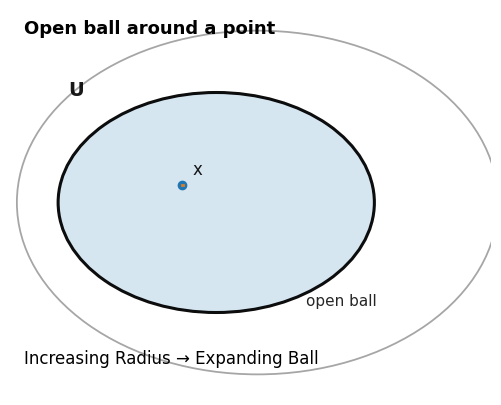

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle, FancyArrowPatch
from matplotlib.animation import FuncAnimation, PillowWriter

# ---------- Parameters ----------
W, H = 7, 5
center_U = (-1.2, 0.0)
U_w, U_h = 4.6, 3.2
x0 = (-1.7, 0.25)
r_max = 1.25

# More frames + slower playback
frames_grow = 55
frames_hold = 18
frames_bad  = 45
frames_total = frames_grow + frames_hold + frames_bad

# Slower timing controls
interval_ms = 140   # time between frames (ms) for interactive preview players
fps = 7             # frames per second in the saved GIF (lower = slower)

# ---------- Helper: point-in-ellipse ----------
def inside_ellipse(pt, c, w, h):
    x, y = pt
    cx, cy = c
    return ((x - cx) / (w / 2))**2 + ((y - cy) / (h / 2))**2 < 1.0

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(W, H))
ax.set_xlim(-4.2, 2.8)
ax.set_ylim(-2.8, 2.8)
ax.set_aspect("equal")
ax.axis("off")

# Background boundary (subtle)
space = Ellipse((-0.6, 0.0), 7.0, 5.0, fill=False, linewidth=1.3, alpha=0.35)
ax.add_patch(space)

# Good example: set U (a neighborhood)
U_fill = Ellipse(center_U, U_w, U_h, linewidth=0.0, alpha=0.18)
U_edge = Ellipse(center_U, U_w, U_h, fill=False, linewidth=2.2, alpha=0.95)
ax.add_patch(U_fill)
ax.add_patch(U_edge)

# Point x
pt_good, = ax.plot([x0[0]], [x0[1]], marker="o", markersize=6)

# Open ball around x (animated radius)
ball_fill = Circle(x0, 0.01, linewidth=0.0, alpha=0.18)
ball_edge = Circle(x0, 0.01, fill=False, linewidth=2.0, alpha=0.95)
ax.add_patch(ball_fill)
ax.add_patch(ball_edge)

# Radius segment
radius_line, = ax.plot([x0[0], x0[0] + 0.01], [x0[1], x0[1]], linewidth=2.0, alpha=0.85)

# Text
title = ax.text(-4.0, 2.45, "", fontsize=13, fontweight="bold")
label_U = ax.text(center_U[0] - 2.15, center_U[1] + 1.55, "U", fontsize=14, fontweight="bold", alpha=0.9)
label_x = ax.text(x0[0] + 0.15, x0[1] + 0.15, "x", fontsize=12, alpha=0.9)
label_ball = ax.text(x0[0] - 0.30, x0[1] - 1.65, "open ball", fontsize=11, alpha=0.0)
status = ax.text(-4.0, -2.35, "", fontsize=12)

# Bad example: a set containing x but NOT a neighborhood (has a "hole")
U_bad_center = (1.1, 0.0)
U_bad = Ellipse(U_bad_center, 3.2, 2.6, linewidth=0.0, alpha=0.0)
U_bad_edge = Ellipse(U_bad_center, 3.2, 2.6, fill=False, linewidth=2.2, alpha=0.0)

hole_center = (0.35, 0.10)
hole_fill = Circle(hole_center, 0.55, facecolor="white", linewidth=0.0, alpha=0.0)
hole_edge = Circle(hole_center, 0.55, fill=False, linewidth=2.0, alpha=0.0)

ax.add_patch(U_bad)
ax.add_patch(U_bad_edge)
ax.add_patch(hole_fill)
ax.add_patch(hole_edge)

x_bad = (0.55, 0.15)
pt_bad, = ax.plot([x_bad[0]], [x_bad[1]], marker="o", markersize=6, alpha=0.0)
label_badU = ax.text(U_bad_center[0] - 1.6, U_bad_center[1] + 1.35, "U", fontsize=14, fontweight="bold", alpha=0.0)
label_badx = ax.text(x_bad[0] + 0.15, x_bad[1] + 0.15, "x", fontsize=12, alpha=0.0)

bad_ball_fill = Circle(x_bad, 0.01, linewidth=0.0, alpha=0.0)
bad_ball_edge = Circle(x_bad, 0.01, fill=False, linewidth=2.0, alpha=0.0)
ax.add_patch(bad_ball_fill)
ax.add_patch(bad_ball_edge)

# Optional dashed arrow hinting the "hole"
leak_arrow = FancyArrowPatch(
    (0.9, 0.0), hole_center,
    arrowstyle='-|>', mutation_scale=14,
    linewidth=1.8, linestyle="dashed", alpha=0.0
)
ax.add_patch(leak_arrow)

# ---------- Alpha helpers ----------
def set_good_alpha(a: float):
    U_fill.set_alpha(0.18 * a)
    U_edge.set_alpha(0.95 * a)
    pt_good.set_alpha(a)
    label_U.set_alpha(0.9 * a)
    label_x.set_alpha(0.9 * a)
    ball_fill.set_alpha(0.18 * a)
    ball_edge.set_alpha(0.95 * a)
    radius_line.set_alpha(0.85 * a)

def set_bad_alpha(a: float):
    U_bad.set_alpha(0.18 * a)
    U_bad_edge.set_alpha(0.95 * a)
    hole_fill.set_alpha(1.0 * a)
    hole_edge.set_alpha(0.95 * a)
    pt_bad.set_alpha(a)
    label_badU.set_alpha(0.9 * a)
    label_badx.set_alpha(0.9 * a)
    bad_ball_fill.set_alpha(0.18 * a)
    bad_ball_edge.set_alpha(0.95 * a)
    leak_arrow.set_alpha(0.9 * a)

# ---------- Animation update ----------
def update(frame: int):
    # Phase 1: growing ball
    if frame < frames_grow:
        t = frame / (frames_grow - 1)
        r = 0.02 + t * r_max

        title.set_text("Open ball around a point")
        label_ball.set_text("open ball")
        label_ball.set_alpha(0.85)

        set_good_alpha(1.0)
        set_bad_alpha(0.0)

        ball_fill.set_radius(r)
        ball_edge.set_radius(r)
        radius_line.set_data([x0[0], x0[0] + r], [x0[1], x0[1]])

        # check if boundary samples stay inside U
        angles = np.linspace(0, 2*np.pi, 64)
        boundary = np.c_[x0[0] + r*np.cos(angles), x0[1] + r*np.sin(angles)]
        ok = all(inside_ellipse(tuple(p), center_U, U_w, U_h) for p in boundary)

        status.set_text(
            "Increasing Radius → Expanding Ball"
            if ok else
            "Large radius → ball escapes."
        )
        return

    # Phase 2: hold the key idea (neighborhood)
    if frame < frames_grow + frames_hold:
        r = r_max * 0.80
        title.set_text("Neighborhood: Contains an Entire Ball")
        status.set_text("Neighborhood = point + full ball.")
        label_ball.set_text("Open Ball Inside the Set")
        label_ball.set_alpha(0.85)

        set_good_alpha(1.0)
        set_bad_alpha(0.0)

        ball_fill.set_radius(r)
        ball_edge.set_radius(r)
        radius_line.set_data([x0[0], x0[0] + r], [x0[1], x0[1]])
        return

    # Phase 3: non-neighborhood example
    k = frame - (frames_grow + frames_hold)
    t = k / (frames_bad - 1)

    good_a = max(0.0, 1.0 - 1.2*t)
    bad_a = min(1.0, 1.2*t)

    set_good_alpha(good_a)
    set_bad_alpha(bad_a)

    title.set_text("Point included, no neighborhood.")
    status.set_text("Hole ⇒ Ball Leaks.")
    label_ball.set_text("a ball leaks out")
    label_ball.set_position((x_bad[0] - 0.45, x_bad[1] - 1.65))
    label_ball.set_alpha(0.85 * bad_a)

    # animate shrinking ball (still intersects the hole visually)
    r = max(0.20, 0.85 - 0.45*t)
    bad_ball_fill.set_radius(r)
    bad_ball_edge.set_radius(r)
    return

# ---------- Build and save ----------
anim = FuncAnimation(fig, update, frames=frames_total, interval=interval_ms)

out_path = "open_ball_neighborhood_animation_slow.gif"
anim.save(out_path, writer=PillowWriter(fps=fps))

print("Saved:", out_path)

# **How to Read the Diagram: Open Ball & Neighborhood**

The diagram above visualizes the two closely related notions in a metric space $(X,d)$: an **open ball** and a **neighborhood**.


- The **blue dot** marks a point $x\in X$.

- The **teal disk** represents the **open ball** centered at $x$ with radius $r>0$, denoted $B(x,r)$. By definition,
$$
B(x,r)=\{\,y\in X:\ d(x,y)<r\,\}.
$$

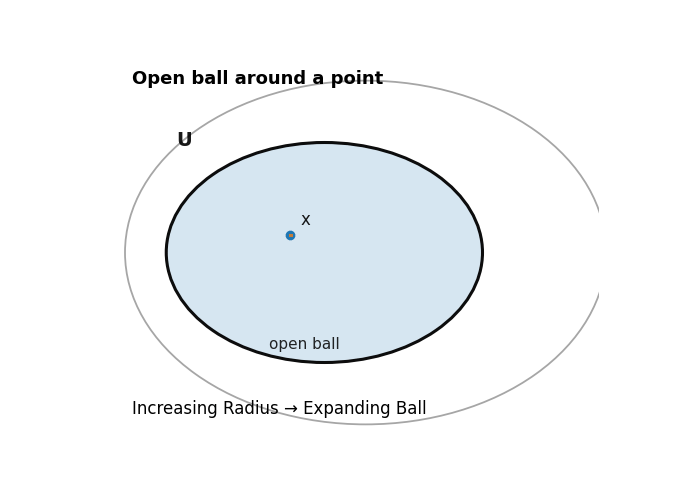

Geometrically, this means that starting at $x$, collect all points whose distance from $x$ (measured by the metric $d$) is **strictly less** than $r$. The segment drawn from $x$ to the teal boundary is a visual cue for the radius $r$. (The boundary circle itself is not meant to imply that points with distance exactly $r$ are included; the key condition is $d(x,y)<r$.)

- The blue region represents a set $U\subseteq X$ that contains the point $x$.
In general, simply having $x\in U$ does not automatically make $U$ a neighborhood of $x$. What matters is whether $U$ contains a whole ball around $x$.

- In the diagram, the teal ball lies entirely inside the blue region, expressing the inclusion

$$
B(x,r)\subseteq U.
$$

This inclusion is the precise mathematical content of the phrase *$U$ contains an open ball around $x$.*

In [ ]:
# Plotly animation (Colab-ready): Open ball → Neighborhood → Not a neighborhood
# Includes fading of ALL good elements in Phase 3 (U, x, ball) + set/point annotations that fade.
# Slider shifted upward.

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "colab"

# ---------------- helpers ----------------
def circle_xy(cx, cy, r, n=240):
    t = np.linspace(0, 2*np.pi, n)
    return cx + r*np.cos(t), cy + r*np.sin(t)

def ellipse_xy(cx, cy, a, b, n=240):
    t = np.linspace(0, 2*np.pi, n)
    return cx + a*np.cos(t), cy + b*np.sin(t)

def lerp(a, b, t):
    return a + (b - a) * t

# ---------------- geometry ----------------
center_U = (-1.2, 0.0)
U_a, U_b = 4.6/2, 3.2/2
x0 = (-1.7, 0.25)

U_bad_center = (1.1, 0.0)
U_bad_a, U_bad_b = 3.2/2, 2.6/2
hole_center = (0.35, 0.10)
hole_r = 0.55
x_bad = (0.55, 0.15)

xlim = (-4.2, 2.8)
ylim = (-2.8, 2.8)

# ---------------- animation schedule ----------------
N1 = 45   # Phase 1: ball grows
N2 = 18   # Phase 2: hold neighborhood
N3 = 35   # Phase 3: fade to non-neighborhood
N  = N1 + N2 + N3

r_min  = 0.05
r_max  = 1.25
r_safe = 0.80 * r_max

# Precompute outlines
Ux, Uy   = ellipse_xy(center_U[0], center_U[1], U_a, U_b)
UBx, UBy = ellipse_xy(U_bad_center[0], U_bad_center[1], U_bad_a, U_bad_b)
Hx, Hy   = circle_xy(hole_center[0], hole_center[1], hole_r)

Bx0, By0   = circle_xy(x0[0], x0[1], r_min)
BBx0, BBy0 = circle_xy(x_bad[0], x_bad[1], r_min)

# ---------------- base figure ----------------
fig = go.Figure(
    data=[
        # 0: Good U fill
        go.Scatter(
            x=Ux, y=Uy, mode="lines",
            line=dict(width=3, color="rgba(0,0,0,0.55)"),
            fill="toself", fillcolor="rgba(0,121,107,0.10)",
            hoverinfo="skip"
        ),
        # 1: Good U border
        go.Scatter(
            x=Ux, y=Uy, mode="lines",
            line=dict(width=3, color="rgba(0,0,0,0.65)"),
            hoverinfo="skip"
        ),
        # 2: Good point x
        go.Scatter(
            x=[x0[0]], y=[x0[1]], mode="markers",
            marker=dict(size=10, color="rgba(0,0,0,0.85)"),
            hoverinfo="skip"
        ),
        # 3: Good ball fill
        go.Scatter(
            x=Bx0, y=By0, mode="lines",
            line=dict(width=2, color="rgba(0,0,0,0.40)"),
            fill="toself", fillcolor="rgba(25,118,210,0.12)",
            hoverinfo="skip"
        ),
        # 4: Good ball border
        go.Scatter(
            x=Bx0, y=By0, mode="lines",
            line=dict(width=3, color="rgba(0,0,0,0.55)"),
            hoverinfo="skip"
        ),

        # 5: Bad U fill (hidden initially)
        go.Scatter(
            x=UBx, y=UBy, mode="lines",
            line=dict(width=3, color="rgba(0,0,0,0.55)"),
            fill="toself", fillcolor="rgba(0,121,107,0.10)",
            hoverinfo="skip", opacity=0.0
        ),
        # 6: Bad U border
        go.Scatter(
            x=UBx, y=UBy, mode="lines",
            line=dict(width=3, color="rgba(0,0,0,0.65)"),
            hoverinfo="skip", opacity=0.0
        ),
        # 7: Hole (white cut-out)
        go.Scatter(
            x=Hx, y=Hy, mode="lines",
            line=dict(width=2, color="rgba(0,0,0,0.55)"),
            fill="toself", fillcolor="white",
            hoverinfo="skip", opacity=0.0
        ),
        # 8: Bad point x
        go.Scatter(
            x=[x_bad[0]], y=[x_bad[1]], mode="markers",
            marker=dict(size=10, color="rgba(0,0,0,0.85)"),
            hoverinfo="skip", opacity=0.0
        ),
        # 9: Bad ball fill
        go.Scatter(
            x=BBx0, y=BBy0, mode="lines",
            line=dict(width=2, color="rgba(0,0,0,0.40)"),
            fill="toself", fillcolor="rgba(25,118,210,0.12)",
            hoverinfo="skip", opacity=0.0
        ),
        # 10: Bad ball border
        go.Scatter(
            x=BBx0, y=BBy0, mode="lines",
            line=dict(width=3, color="rgba(0,0,0,0.55)"),
            hoverinfo="skip", opacity=0.0
        ),
    ]
)

# ---------------- frames ----------------
frames = []
for k in range(N):
    good_alpha = 1.0
    bad_alpha = 0.0

    if k < N1:
        t = k / (N1 - 1)
        r = lerp(r_min, r_max, t)
        title = "Open ball"
        subtitle = "Ball expands with increasing radius."
    elif k < N1 + N2:
        r = r_safe
        title = "Neighborhood"
        subtitle = "A full ball fits inside."
    else:
        kk = k - (N1 + N2)
        t = kk / (N3 - 1)

        good_alpha = max(0.0, 1.0 - 1.2*t)
        bad_alpha  = min(1.0, 1.2*t)

        r = max(0.20, 0.85 - 0.45*t)
        title = "Not a neighborhood"
        subtitle = "Due to a hole, no small ball stays inside."

    # Geometry
    Bx, By   = circle_xy(x0[0], x0[1], r)
    BBx, BBy = circle_xy(x_bad[0], x_bad[1], r)

    # Opacity mapping
    good_U_fill_op    = 0.30 * good_alpha
    good_U_edge_op    = 0.95 * good_alpha
    good_point_op     = 1.00 * good_alpha
    good_ball_fill_op = 0.18 * good_alpha
    good_ball_edge_op = 0.55 * good_alpha

    bad_U_fill_op     = 0.30 * bad_alpha
    bad_U_edge_op     = 0.95 * bad_alpha
    hole_op           = 1.00 * bad_alpha
    bad_point_op      = 1.00 * bad_alpha
    bad_ball_fill_op  = 0.18 * bad_alpha
    bad_ball_edge_op  = 0.55 * bad_alpha

    # Labels that fade with their sets
    ann = [
        # Title/status
        dict(
            x=0.5, y=1.10, xref="paper", yref="paper",
            text=f"<b>{title}</b><br>"
                 f"<span style='font-size:12px;color:rgba(60,60,60,0.85)'>{subtitle}</span>",
            showarrow=False, align="center"
        ),
        # Good set label U
        dict(
            x=center_U[0]-2.15, y=center_U[1]+1.55, xref="x", yref="y",
            text="<b>U</b>",
            showarrow=False,
            font=dict(size=16, color=f"rgba(0,0,0,{0.75*good_alpha})")
        ),
        # Good point label x
        dict(
            x=x0[0]+0.15, y=x0[1]+0.15, xref="x", yref="y",
            text="x",
            showarrow=False,
            font=dict(size=14, color=f"rgba(0,0,0,{0.75*good_alpha})")
        ),
        # Bad set label U
        dict(
            x=U_bad_center[0]-1.6, y=U_bad_center[1]+1.35, xref="x", yref="y",
            text="<b>U</b>",
            showarrow=False,
            font=dict(size=16, color=f"rgba(0,0,0,{0.75*bad_alpha})")
        ),
        # Bad point label x
        dict(
            x=x_bad[0]+0.15, y=x_bad[1]+0.15, xref="x", yref="y",
            text="x",
            showarrow=False,
            font=dict(size=14, color=f"rgba(0,0,0,{0.75*bad_alpha})")
        ),
        # Hole label
        dict(
            x=hole_center[0], y=hole_center[1]-0.85, xref="x", yref="y",
            text="hole",
            showarrow=False,
            font=dict(size=13, color=f"rgba(0,0,0,{0.60*bad_alpha})")
        ),
    ]

    frames.append(
        go.Frame(
            name=str(k),
            data=[
                # 0 good U fill
                go.Scatter(opacity=good_U_fill_op),
                # 1 good U edge
                go.Scatter(opacity=good_U_edge_op),
                # 2 good point
                go.Scatter(opacity=good_point_op),

                # 3 good ball fill
                go.Scatter(x=Bx, y=By, opacity=good_ball_fill_op),
                # 4 good ball edge
                go.Scatter(x=Bx, y=By, opacity=good_ball_edge_op),

                # 5 bad U fill
                go.Scatter(opacity=bad_U_fill_op),
                # 6 bad U edge
                go.Scatter(opacity=bad_U_edge_op),
                # 7 hole
                go.Scatter(opacity=hole_op),
                # 8 bad point
                go.Scatter(opacity=bad_point_op),

                # 9 bad ball fill
                go.Scatter(x=BBx, y=BBy, opacity=bad_ball_fill_op),
                # 10 bad ball edge
                go.Scatter(x=BBx, y=BBy, opacity=bad_ball_edge_op),
            ],
            layout=go.Layout(annotations=ann)
        )
    )

fig.frames = frames

# ---------------- controls ----------------
fig.update_layout(
    width=900,
    height=520,
    margin=dict(l=30, r=30, t=95, b=30),
    xaxis=dict(range=list(xlim), showgrid=False, zeroline=False, visible=False),
    yaxis=dict(range=list(ylim), showgrid=False, zeroline=False, visible=False),
    showlegend=False,

    updatemenus=[
        dict(
            type="buttons",
            direction="left",
            x=0.08, y=1.04, xanchor="left", yanchor="bottom",
            buttons=[
                dict(
                    label="Play",
                    method="animate",
                    args=[None, dict(
                        frame=dict(duration=140, redraw=True),
                        transition=dict(duration=0),
                        fromcurrent=True
                    )]
                ),
                dict(
                    label="Pause",
                    method="animate",
                    args=[[None], dict(
                        frame=dict(duration=0, redraw=False),
                        transition=dict(duration=0),
                        mode="immediate"
                    )]
                ),
            ],
        )
    ],

    # Slider shifted upward (y increased)
    sliders=[
        dict(
            x=0.08, y=1.015, xanchor="left", yanchor="top",
            len=0.86,
            currentvalue=dict(prefix="Frame: ", font=dict(size=12)),
            steps=[
                dict(
                    method="animate",
                    args=[[str(k)], dict(
                        mode="immediate",
                        frame=dict(duration=0, redraw=True),
                        transition=dict(duration=0)
                    )],
                    label=""
                )
                for k in range(N)
            ],
        )
    ],
)

# Initial annotation set (frame 0)
fig.update_layout(
    annotations=[
        dict(
            x=0.5, y=1.10, xref="paper", yref="paper",
            text="<b>Open ball</b><br>"
                 "<span style='font-size:12px;color:rgba(60,60,60,0.85)'>Ball expands with increasing radius.</span>",
            showarrow=False, align="center"
        ),
        dict(
            x=center_U[0]-2.15, y=center_U[1]+1.55, xref="x", yref="y",
            text="<b>U</b>",
            showarrow=False, font=dict(size=16, color="rgba(0,0,0,0.75)")
        ),
        dict(
            x=x0[0]+0.15, y=x0[1]+0.15, xref="x", yref="y",
            text="x",
            showarrow=False, font=dict(size=14, color="rgba(0,0,0,0.75)")
        ),
    ]
)

fig.show()

# **How the Definition Justifies the Computation**
The definition of convergence in a metric space
$$
x_n \to a
\quad\Longleftrightarrow\quad
(\forall \varepsilon>0)(\exists N\in\mathbb{N})(\forall n\ge N)\;
d(x_n,a)<\varepsilon
$$

is often perceived as abstract when first encountered. However, the examples we solved illustrate that the definition naturally leads to
**explicit numerical procedures**.

## **Step 1: Translate the Definition into an Inequality**

For a proposed limit $a$, the definition requires that we control the
distance between the sequence and the limit:

$$
d(x_n,a)=|x_n-a|.
$$

Thus the mathematical task becomes solving the inequality

$$
|x_n-a|<\varepsilon.
$$

## **Step 2: Solve the Inequality Symbolically**

For the sequence $x_n=\frac{1}{n}$ we obtained

$$
|x_n-0|=\frac{1}{n}<\varepsilon
\quad\Longleftrightarrow\quad
n>\frac{1}{\varepsilon}.
$$

For the sequence $x_n=\frac{n}{n+1}$ we computed

$$
\left|\frac{n}{n+1}-1\right|
=\frac{1}{n+1}
<\varepsilon
\quad\Longleftrightarrow\quad
n>\frac{1}{\varepsilon}-1.
$$

These inequalities describe precisely how large $n$ must be for the
terms of the sequence to lie inside the $\varepsilon$--ball around the limit.

## **Step 3: Produce an Explicit Threshold $N(\varepsilon)$**

Since the definition requires an integer index, we convert the inequality into an explicit function:

$$
N(\varepsilon)=
\left\lceil\frac{1}{\varepsilon}\right\rceil
\quad\text{or}\quad
N(\varepsilon)=
\left\lceil\frac{1}{\varepsilon}\right\rceil+1.
$$

Once $N(\varepsilon)$ is chosen, the definition guarantees that

$$
n\ge N(\varepsilon)
\quad\Longrightarrow\quad
|x_n-a|<\varepsilon .
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import ceil

def N_for_1_over_n(eps):
    return int(ceil(1/eps) + 1)

def N_for_n_over_nplus1(eps):
    return int(ceil(1/eps))

def demo_table(eps_list):
    rows = []
    for eps in eps_list:
        N1 = N_for_1_over_n(eps)
        N2 = N_for_n_over_nplus1(eps)

        n1 = N1
        n1_prev = max(1, N1-1)
        d1 = abs(1/n1 - 0)
        d1_prev = abs(1/n1_prev - 0)

        n2 = N2
        n2_prev = max(1, N2-1)
        d2 = abs(n2/(n2+1) - 1)
        d2_prev = abs(n2_prev/(n2_prev+1) - 1)

        rows.append({
            "eps": eps,
            "N(eps) for 1/n": N1,
            "|x_N-0|": d1,
            "|x_{N-1}-0|": d1_prev,
            "N(eps) for n/(n+1)": N2,
            "|y_N-1|": d2,
            "|y_{N-1}-1|": d2_prev,
        })
    return pd.DataFrame(rows)

eps_list = [0.5, 0.2, 0.1, 0.05, 0.01]
df = demo_table(eps_list)
df

,eps,N(eps) for 1/n,|x_N-0|,|x_{N-1}-0|,N(eps) for n/(n+1),|y_N-1|,|y_{N-1}-1|
0,0.50,3,0.333333,0.50,2,0.333333,0.50
1,0.20,6,0.166667,0.20,5,0.166667,0.20
2,0.10,11,0.090909,0.10,10,0.090909,0.10
3,0.05,21,0.047619,0.05,20,0.047619,0.05
4,0.01,101,0.009901,0.01,100,0.009901,0.01


## **Step 4: Algorithmic Interpretation**

The proof can be viewed as an algorithm:
- Choose a tolerance $\varepsilon>0$.
- Compute $N(\varepsilon)$ from the derived formula.
- Verify that for all $n\ge N(\varepsilon)$,

$$
|x_n-a|<\varepsilon .
$$


This procedure converts the abstract logical statement

$$
(\forall\varepsilon)(\exists N)(\forall n\ge N)
$$

into a concrete computational rule.

## **Step 5: Numerical Verification via Computation**

Using Python and graphical visualization, we plotted
$$
|x_n-a|
$$

against $n$ for both sequences. The graphs clearly demonstrate that after the index $N(\varepsilon)$, all terms remain below the horizontal line $y=\varepsilon$.

Thus the computational experiment visually confirms the theoretical statement:

$$
n\ge N(\varepsilon)
\quad\Longrightarrow\quad
x_n\in B(a,\varepsilon).
$$

## **Conceptual Takeaway**

The definition of convergence is not merely symbolic logic. It provides a precise mechanism that allows us to:

- Derive explicit bounds,
- Construct algorithms determining when a sequence is sufficiently close
to its limit,
- And verify the result computationally.


In this sense, the $\varepsilon$-$N$ definition forms the bridge between
**rigorous analysis** and **numerical verification**.


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1-NvUXPPN8d1TuJ2o46PmKI_RpTC2o7eiSDpGRRwvmmc/edit#gid=0


Below is a beginner-friendly Python script that makes the two examples computationally engaging with separate figures. Its purpose is not to replace the $\varepsilon$-$N$ proofs, but to **operationalize** them: given a tolerance $\varepsilon>0$, it computes a concrete index $N(\varepsilon)$ and then checks & visualizes that the tail of the sequence indeed lies inside the $\varepsilon$-ball.

## **Computational Goal (Turning Logic Into An Algorithm)**

The mathematical definition

$$
(\forall \varepsilon>0)(\exists N\in\mathbb{N})(\forall n\ge N)\;|x_n-a|<\varepsilon
$$

naturally suggests an algorithmic workflow:

- **Choose The Accuracy:** $\varepsilon>0$ (user input).
- **Derive a Bound:** by solving the inequality $|x_n-a|<\varepsilon$ for $n$.
- **Convert to an Integer Threshold:** by defining a function $N(\varepsilon)$ (typically using $\lceil\cdot\rceil$).
- **Verify Numerically:** that for all sampled $n\ge N(\varepsilon)$, the inequality holds.


## **What the Script Does (Four Computational Experiments)**


- **A Table Check for a Few $\varepsilon$ Values:** For several tolerances $\varepsilon$, the script prints a table containing

$$
N(\varepsilon),\qquad |x_{N(\varepsilon)}-a|,\qquad |x_{N(\varepsilon)-1}-a|,
$$

so the reader can see a concrete boundary effect:

$$
|x_{N(\varepsilon)}-a|<\varepsilon
\quad\text{while often}\quad
|x_{N(\varepsilon)-1}-a|\ge \varepsilon,
$$

which matches the logic ``$N$ is where the tail condition starts.''

- **Distance Plot for $x_n=\tfrac{1}{n}\to 0$:** It plots the function of the discrete index

$$
n\longmapsto |x_n-0|=\frac{1}{n},
$$

and overlays a horizontal line $y=\varepsilon$ and a vertical line $n=N(\varepsilon)$.

The visual statement is:

$$
n\ge N(\varepsilon)\quad\Rightarrow\quad |x_n|<\varepsilon.
$$

- **Distance Plot for $y_n=\tfrac{n}{n+1}\to 1$:** It plots

$$
n\longmapsto \left|y_n-1\right|=\frac{1}{n+1},
$$

again with the two guide-lines $y=\varepsilon$ and $n=N(\varepsilon)$, making the same $\varepsilon$-$N$ implication visible.

 - **Growth of $N(\varepsilon)$ as $\varepsilon$ Shrinks:** For a range of tolerances $\varepsilon$, it plots the map

$$
\varepsilon \longmapsto N(\varepsilon),
$$

typically using a logarithmic scale on the $\varepsilon$-axis. This is the numerical counterpart of the theoretical fact that demanding a smaller error
requires a larger index:

$$
\varepsilon_1<\varepsilon_2 \quad\Rightarrow\quad N(\varepsilon_1)\ge N(\varepsilon_2).
$$

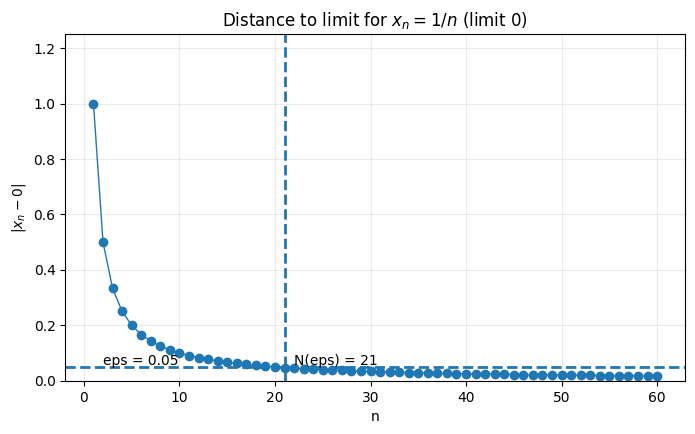

In [ ]:
# -----------------------------
# Plot 1: x_n = 1/n -> 0
# Separate figure (no subplots)
# -----------------------------
eps = 0.05
N = N_for_1_over_n(eps)

n_max = 60
n = np.arange(1, n_max+1)
x = 1/n
dist = np.abs(x - 0)

plt.figure(figsize=(8,4.5))
plt.plot(n, dist, marker='o', linewidth=1)
plt.axhline(eps, linestyle='--', linewidth=2)
plt.axvline(N, linestyle='--', linewidth=2)
plt.title(r"Distance to limit for $x_n = 1/n$ (limit $0$)")
plt.xlabel("n")
plt.ylabel(r"$|x_n - 0|$")
plt.text(N+1, eps*1.15, f"N(eps) = {N}", fontsize=10)
plt.text(2, eps*1.15, f"eps = {eps}", fontsize=10)
plt.ylim(0, max(dist[0], eps)*1.25)
plt.grid(True, alpha=0.25)
plt.show()


## **Interpretation:**
In analysis, proofs establish existence of $N(\varepsilon)$ by reasoning.
In computation, we implement the same reasoning as a routine:

$$
\varepsilon \mapsto N(\varepsilon),
$$

and then **audit** the claim numerically on a finite but informative range of indices.This is a practical bridge between the abstract quantifiers and concrete numerical evidence, and it trains the reader to construct $N(\varepsilon)$ systematically for new sequences.

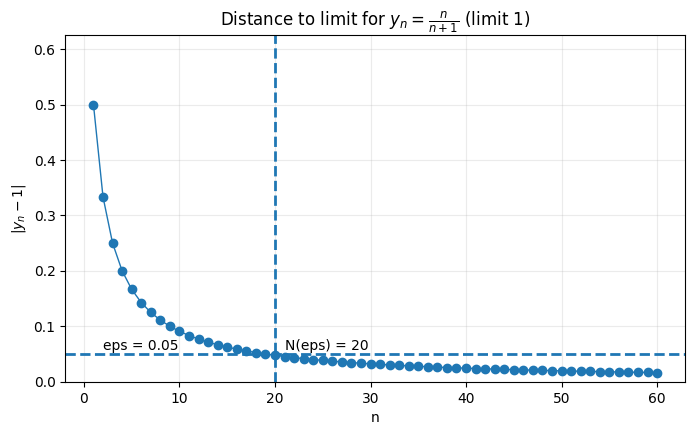

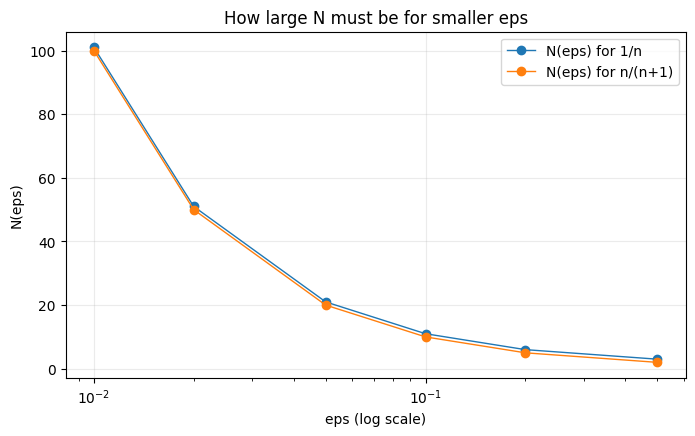

In [ ]:
# -----------------------------
# Plot 2: y_n = n/(n+1) -> 1
# Separate figure (no subplots)
# -----------------------------
eps = 0.05
N = N_for_n_over_nplus1(eps)

n_max = 60
n = np.arange(1, n_max+1)
y = n/(n+1)
dist = np.abs(y - 1)

plt.figure(figsize=(8,4.5))
plt.plot(n, dist, marker='o', linewidth=1)
plt.axhline(eps, linestyle='--', linewidth=2)
plt.axvline(N, linestyle='--', linewidth=2)
plt.title(r"Distance to limit for $y_n = \frac{n}{n+1}$ (limit $1$)")
plt.xlabel("n")
plt.ylabel(r"$|y_n - 1|$")
plt.text(N+1, eps*1.15, f"N(eps) = {N}", fontsize=10)
plt.text(2, eps*1.15, f"eps = {eps}", fontsize=10)
plt.ylim(0, max(dist[0], eps)*1.25)
plt.grid(True, alpha=0.25)
plt.show()

# -----------------------------
# Plot 3: N(eps) growth (separate figure)
# We'll show eps values on a log scale for readability.
# -----------------------------
eps_vals = np.array([0.5, 0.2, 0.1, 0.05, 0.02, 0.01])
N1_vals = np.array([N_for_1_over_n(e) for e in eps_vals])
N2_vals = np.array([N_for_n_over_nplus1(e) for e in eps_vals])

plt.figure(figsize=(8,4.5))
plt.plot(eps_vals, N1_vals, marker='o', linewidth=1, label="N(eps) for 1/n")
plt.plot(eps_vals, N2_vals, marker='o', linewidth=1, label="N(eps) for n/(n+1)")
plt.xscale('log')
plt.title("How large N must be for smaller eps")
plt.xlabel("eps (log scale)")
plt.ylabel("N(eps)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

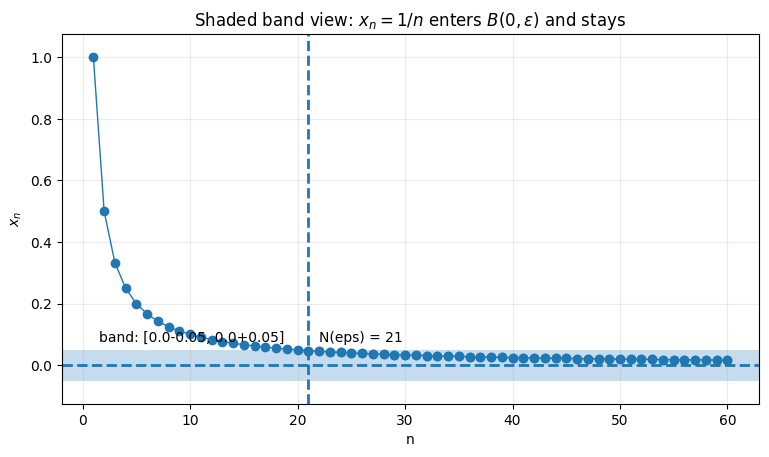

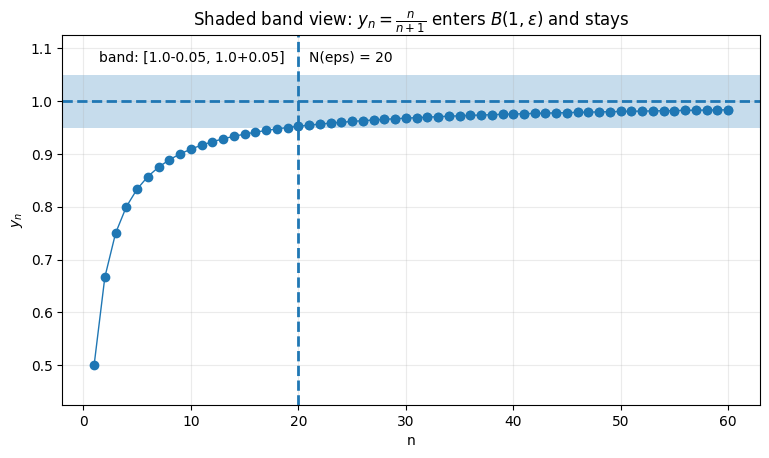

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

# -----------------------------
# N(eps) from your proofs
# -----------------------------
def N_for_1_over_n(eps):
    return int(ceil(1/eps) + 1)

def N_for_n_over_nplus1(eps):
    return int(ceil(1/eps))

# -----------------------------
# Helper: shaded band plot
# -----------------------------
def plot_band_sequence(n, seq_values, a, eps, N, title, y_label):
    lower = a - eps
    upper = a + eps

    plt.figure(figsize=(9, 4.8))

    # Shaded epsilon-band (the "ball condition" on y-axis)
    plt.axhspan(lower, upper, alpha=0.25)
    plt.axhline(a, linestyle="--", linewidth=2)  # limit line

    # Plot sequence values
    plt.plot(n, seq_values, marker="o", linewidth=1)

    # Highlight where the tail starts (n >= N)
    plt.axvline(N, linestyle="--", linewidth=2)
    plt.scatter(n[n >= N], seq_values[n >= N], s=35)  # emphasize tail points

    # Labels / text (kept concise)
    plt.title(title)
    plt.xlabel("n")
    plt.ylabel(y_label)

    # Put short annotations in safe locations
    y_text = upper + (upper - lower) * 0.25 if eps > 0 else a
    plt.text(1.5, y_text, f"band: [{a}-{eps}, {a}+{eps}]", fontsize=10)
    plt.text(N + 1, y_text, f"N(eps) = {N}", fontsize=10)

    # Set y-limits to show band clearly
    ymin = min(seq_values.min(), lower) - abs(eps) * 1.5
    ymax = max(seq_values.max(), upper) + abs(eps) * 1.5
    plt.ylim(ymin, ymax)

    plt.grid(True, alpha=0.25)
    plt.show()

# -----------------------------
# Figure A: x_n = 1/n -> 0
# -----------------------------
eps = 0.05
a = 0.0
N = N_for_1_over_n(eps)

n_max = 60
n = np.arange(1, n_max + 1)
x = 1 / n

plot_band_sequence(
    n=n,
    seq_values=x,
    a=a,
    eps=eps,
    N=N,
    title=r"Shaded band view: $x_n = 1/n$ enters $B(0,\varepsilon)$ and stays",
    y_label=r"$x_n$"
)

# -----------------------------
# Figure B: y_n = n/(n+1) -> 1
# -----------------------------
eps = 0.05
a = 1.0
N = N_for_n_over_nplus1(eps)

y = n / (n + 1)

plot_band_sequence(
    n=n,
    seq_values=y,
    a=a,
    eps=eps,
    N=N,
    title=r"Shaded band view: $y_n = \frac{n}{n+1}$ enters $B(1,\varepsilon)$ and stays",
    y_label=r"$y_n$"
)

# **What the Shaded-Band Plots Verify Numerically**

The Python code produces a **numerical visualization** of the $\varepsilon$--$N$ definition of convergence. Fix a proposed limit $a$ and a tolerance $\varepsilon>0$. In $(\mathbb{R},|\cdot|)$ the open ball is

$$
B(a,\varepsilon)=\{x\in \mathbb{R}:\ |x-a|<\varepsilon\}.
$$

On the graph, this condition is represented as a **horizontal shaded band**:

$$
a-\varepsilon \;<\; y \;<\; a+\varepsilon.
$$

Thus, a plotted point $(n,x_n)$ lies inside the band exactly when

$$
x_n\in B(a,\varepsilon)
\quad\Longleftrightarrow\quad
|x_n-a|<\varepsilon.
$$

## **How the Code Encodes the Quantifiers**

The definition

$$
(\forall \varepsilon>0)(\exists N\in\mathbb{N})(\forall n\ge N)\; |x_n-a|<\varepsilon
$$

is visualized as follows:

> **1. Fix $\varepsilon$ (Choose Accuracy):** The code sets a numerical value for *eps* and shades the band between $a-\varepsilon$ and $a+\varepsilon$.
>
> **2. Produce $N(\varepsilon)$ (Construct the Tail Index):** Using the explicit formulas derived in the proofs, the code computes
>
>$$ N(\varepsilon)=\left\lceil \frac{1}{\varepsilon}\right\rceil+1
\quad\text{for }x_n=\frac1n,
\qquad N(\varepsilon)=\left\lceil \frac{1}{\varepsilon}\right\rceil \quad\text{for }y_n=\frac{n}{n+1} $$
>
> Then a vertical dashed line at $n=N(\varepsilon)$ is drawn.
>
> **3. Check the Tail Condition (All Later Terms Stay Inside):** All points with indices $n\ge N(\varepsilon)$ are highlighted.
The figure demonstrates that these highlighted points lie inside the shaded band, i.e.

$$
n\ge N(\varepsilon)\quad\Longrightarrow\quad x_n\in (a-\varepsilon,a+\varepsilon).
$$

Graphically this is the statement that, after the dashed vertical line, the sequence enters the band and does not leave it.

## **Interpretation**
These plots do not replace the proof; rather, they provide an **auditable numerical witness** of the logic:

$$
\text{choose }\varepsilon \;\Longrightarrow\; \text{compute }N(\varepsilon)\;\Longrightarrow\;
\text{verify that the tail lies in }B(a,\varepsilon).
$$

In this way the abstract convergence definition becomes a concrete computational routine.

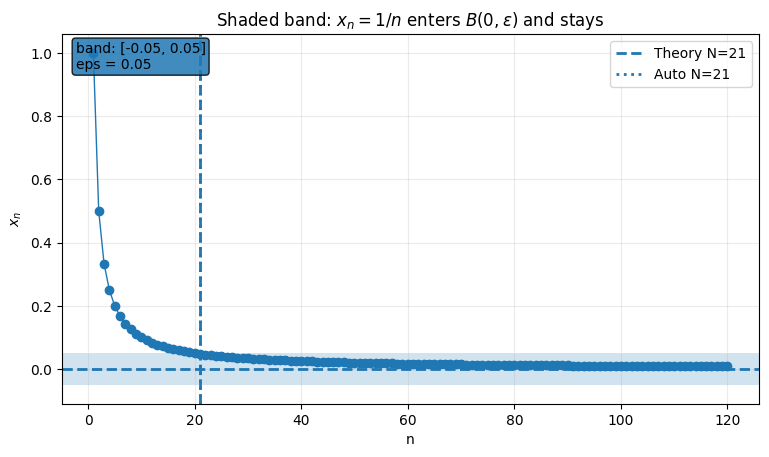

theory N = 21, auto N = 21
✓ Theory N is safe (>= first stable index).


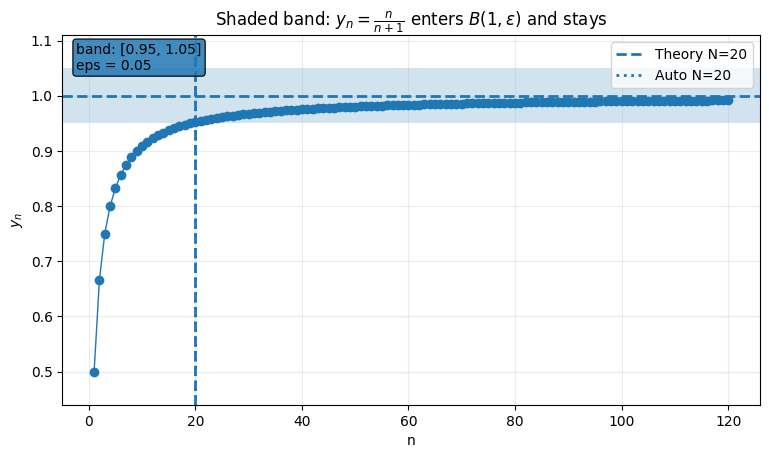

theory N = 20, auto N = 20
✓ Theory N is safe (>= first stable index).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

# -----------------------------
# N(eps) from your proofs
# -----------------------------
def N_for_1_over_n(eps):
    return int(ceil(1/eps) + 1)

def N_for_n_over_nplus1(eps):
    return int(ceil(1/eps))

# -----------------------------
# First stable index (auto check)
# -----------------------------
def first_stable_index(seq_values, a, eps):
    inside = np.abs(seq_values - a) < eps
    suffix_all_inside = np.ones_like(inside, dtype=bool)
    suffix_all_inside[-1] = inside[-1]
    for k in range(len(inside) - 2, -1, -1):
        suffix_all_inside[k] = inside[k] and suffix_all_inside[k + 1]
    idx = np.where(suffix_all_inside)[0]
    if len(idx) == 0:
        return None
    return int(idx[0] + 1)  # 1-based

# -----------------------------
# CLEAN band plot
# -----------------------------
def plot_band_sequence_clean(n, seq_values, a, eps, N_theory, title, y_label):
    lower = a - eps
    upper = a + eps
    N_auto = first_stable_index(seq_values, a, eps)

    fig, ax = plt.subplots(figsize=(9, 4.8))

    # shaded band + limit line
    ax.axhspan(lower, upper, alpha=0.20)
    ax.axhline(a, linestyle="--", linewidth=2)

    # sequence curve
    ax.plot(n, seq_values, marker="o", linewidth=1)

    # vertical lines (use legend instead of text on the plot)
    ax.axvline(N_theory, linestyle="--", linewidth=2, label=f"Theory N={N_theory}")
    if N_auto is not None:
        ax.axvline(N_auto, linestyle=":", linewidth=2, label=f"Auto N={N_auto}")

    # highlight tail from theoretical N
    ax.scatter(n[n >= N_theory], seq_values[n >= N_theory], s=30)

    # Titles/labels
    ax.set_title(title)
    ax.set_xlabel("n")
    ax.set_ylabel(y_label)

    # Put the informational text in the top-left margin (axes coords)
    info_lines = [
        f"band: [{a-eps:.3g}, {a+eps:.3g}]",
        f"eps = {eps}",
    ]
    if N_auto is None:
        info_lines.append("Auto N: not found (increase n_max)")

    ax.text(
        0.02, 0.98,
        "\n".join(info_lines),
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.85)
    )

    # Legend in a clean corner
    ax.legend(loc="upper right", frameon=True)

    # Comfortable y-limits so band isn't glued to the border
    y_min = min(seq_values.min(), lower) - 1.2 * eps
    y_max = max(seq_values.max(), upper) + 1.2 * eps
    ax.set_ylim(y_min, y_max)

    ax.grid(True, alpha=0.25)
    plt.show()

    # Console verification (optional but useful)
    print(f"theory N = {N_theory}, auto N = {N_auto}")
    if N_auto is not None and N_theory >= N_auto:
        print("✓ Theory N is safe (>= first stable index).")
    elif N_auto is not None:
        print("⚠ Theory N is smaller than auto N for this plotted range.")

# -----------------------------
# RUN: Example 1 (1/n -> 0)
# -----------------------------
eps = 0.05
a = 0.0
n_max = 120
n = np.arange(1, n_max + 1)
x = 1 / n
N_theory = N_for_1_over_n(eps)

plot_band_sequence_clean(
    n=n,
    seq_values=x,
    a=a,
    eps=eps,
    N_theory=N_theory,
    title=r"Shaded band: $x_n = 1/n$ enters $B(0,\varepsilon)$ and stays",
    y_label=r"$x_n$"
)

# -----------------------------
# RUN: Example 2 (n/(n+1) -> 1)
# -----------------------------
eps = 0.05
a = 1.0
y = n / (n + 1)
N_theory = N_for_n_over_nplus1(eps)

plot_band_sequence_clean(
    n=n,
    seq_values=y,
    a=a,
    eps=eps,
    N_theory=N_theory,
    title=r"Shaded band: $y_n = \frac{n}{n+1}$ enters $B(1,\varepsilon)$ and stays",
    y_label=r"$y_n$"
)

# **Pseudocode & Iterative Algorithmic View**

## **The $\varepsilon$-$N$ Definition as an Iterative Method**

The convergence statement

$$
x_n\to a
\quad\Longleftrightarrow\quad
(\forall \varepsilon>0)(\exists N\in\mathbb{N})(\forall n\ge N)\; d(x_n,a)<\varepsilon
$$

can be read as an **algorithmic contract:**

> Given a tolerance $\varepsilon$, we must produce an index $N(\varepsilon)$ such that all later terms of the sequence lie inside the ball $B(a,\varepsilon)$.

In numerical terms, this is an **iterative stopping rule:** we keep increasing $n$ until the error $d(x_n,a)$ becomes $<\varepsilon$ and stays $<\varepsilon$ thereafter (for monotone error, this ``stays'' condition is automatic once it holds).


Algorithmic Workflow (Mathematics $\rightarrow$ Computation)}

- **Model:** Identify the metric space $(X,d)$ and the candidate limit $a\in X$.
-  **Error Function:** Define the numerical error at step $n$ by
$$
e(n):=d(x_n,a).
$$
- **Tolerance:** Choose an accuracy level $\varepsilon>0$.
- **Stopping Index:** Find/compute an index $N(\varepsilon)$ such that
$$
n\ge N(\varepsilon)\quad\Longrightarrow\quad e(n)<\varepsilon.
$$
- **Verification:** Check (symbolically or numerically) that the implication holds.

# **Pseudocode: Iteratively Finding $N(\varepsilon)$**

## **Iterative Construction of an $\varepsilon$-index**

Let $(X,d)$ be a metric space, $(x_n)$ a sequence in $X$, and $a\in X$.
Fix $\varepsilon>0$ and define $e(n)=d(x_n,a)$.
Assume that $e(n)$ is eventually nonincreasing (this holds for many standard examples such as $x_n=\frac1n$ or $x_n=\frac{n}{n+1}$ when $a$ is the limit).
Then the following iteration returns an index $N$ such that

$$
n\ge N \ \Rightarrow\ d(x_n,a)<\varepsilon.
$$


### Algorithm: Iterative ε–N Finder

**Input:**  
- tolerance $\varepsilon > 0 $  
- candidate limit $ a $
- metric $ d(\cdot,\cdot) $  
- sequence $ x_n $ (given by a formula or rule)

**Output:**  
An index $ N $ such that for all $n \ge N $,

$$
d(x_n,a) < \varepsilon
$$

 - n ← 1

 - while $d(x_n, a) ≥ ε$ do

 - n ← n + 1

 - end while

 - return N ← n

Goal: Find the first index $ N $ such that  $ |x_n - a| < \varepsilon $ for all later terms.

```python
def find_N(eps, a):
    n = 1
    while abs(x(n) - a) >= eps:
        n = n + 1
    return n
```

## **Why this Matches the Definition**
At each step we compute the \emph{current error} $e(n)=d(x_n,a)$ and compare it to $\varepsilon$. The loop stops at the first index $N$ where $e(N)<\varepsilon$. If, in addition, $e(n)$ is nonincreasing for $n\ge N$, then automatically

$$
n\ge N \ \Rightarrow\ e(n)\le e(N)<\varepsilon,
$$

so the entire tail lies inside $B(a,\varepsilon)$, exactly as required by the definition.

## **Iterative (Computation-Driven)**
Even when no neat algebraic solution is available, we can still \emph{compute} an index $N$ by iterating $n$ until the error is below $\varepsilon$. This is the numerical analogue of the existential quantifier ``$\exists N$''.


### **Optional: A Safer Verification Loop (Tail-Check on a Finite Window)**

#### **Practical Audit (Finite Check on a Window)**

In a computer experiment we only see finitely many terms, so we often add a finite "audit": once we find a candidate $N$, we also check that the next $K$ terms remain inside the band (for a large chosen $K$). This mirrors the mathematical idea of staying inside.


### **Algorithm: ε–N Finder with Finite Audit**

This algorithm numerically verifies the definition of convergence

$$
(\forall \varepsilon > 0)(\exists N)(\forall n \ge N)\; d(x_n,a) < \varepsilon
$$

by computing an index $ N $ and then checking that several later terms
remain inside the $\varepsilon$-ball.

### **Algorithm**

**Input**

- tolerance $ \varepsilon > 0 $
- candidate limit $ a $
- metric $ d(\cdot,\cdot) $
- sequence $ x_n $
- audit length $ K $ (e.g. $K=50$)

**Output**

An index $ N $ such that the sequence appears to satisfy  $ d(x_n,a) < \varepsilon \;  \forall  n \ge N $

- n ← 1

- while d(x_n, a) ≥ ε do

-  n ← n + 1

- end while

- N ← n

- for j = 0 to K do

- assert d(x_{N+j}, a) < ε

- end for

- return N

### **Interpretation**

The algorithm searches sequentially for the first index $ N $
where the error $d(x_n,a)$ becomes smaller than the tolerance
$\varepsilon$.

After this point is found, a **finite audit check** is performed:
the next $K$ terms are tested to confirm that they also satisfy

$$
d(x_{N+j},a) < \varepsilon .
$$

This computational procedure mirrors the logical structure of the definition of convergence and provides a practical numerical verification of the theoretical condition.

## **Code Cell Implementation**

```python
def epsilon_N_finder(x, a, eps, K=50):
    """
    x : function generating sequence x(n)
    a : candidate limit
    eps : tolerance
    K : audit length
    """
    
    n = 1
    
    while abs(x(n) - a) >= eps:
        n += 1
        
    N = n
    
    for j in range(K):
        assert abs(x(N + j) - a) < eps
        
    return N

x = lambda n: 1/n
N = epsilon_N_finder(x, a=0, eps=0.01)
print("Computed N:", N)
```



# **Computational Interpretation of the Two Convergence Proofs**

The two sequences

$$
x_n=\left(\frac35\right)^n
\qquad\text{and}\qquad
y_n=\frac{(-1)^n}{n}
$$

provide two different numerical models of convergence to $0$.

## **(1) Geometric Decay**

For the sequence

$$
x_n=\left(\frac35\right)^n,
$$

the terms are positive and decrease geometrically. The $\varepsilon$--$N$ proof produces an explicit threshold

$$
N(\varepsilon)
=
\max\!\left\{1,\left\lceil \frac{\ln(\varepsilon)}{\ln(3/5)} \right\rceil\right\},
$$
so that

$$
n\ge N(\varepsilon)\quad\Longrightarrow\quad \left(\frac35\right)^n<\varepsilon.
$$

The computational plot represents the ball condition

$$
x_n\in B(0,\varepsilon)
$$

as the shaded horizontal band

$$
(-\varepsilon,\varepsilon).
$$

After the index $N(\varepsilon)$, all plotted terms lie inside this band.

## **(2) Alternating Decay**

For the sequence

$$
y_n=\frac{(-1)^n}{n},
$$

the sign alternates, but the magnitude decreases. Using absolute values,

$$
\left|\frac{(-1)^n}{n}\right|=\frac1n,
$$

so the convergence problem reduces to the same estimate as the basic sequence $\frac1n\to 0$.

An explicit threshold is

$$
N(\varepsilon)=\left\lceil \frac1\varepsilon \right\rceil+1,
$$

and then

$$
n\ge N(\varepsilon)\quad\Longrightarrow\quad \left|\frac{(-1)^n}{n}\right|<\varepsilon.
$$
In the computational plot, this means that although the points oscillate above and below $0$, their oscillation is eventually trapped inside the same band

$$
(-\varepsilon,\varepsilon).
$$

## **(3) Algorithmic Perspective**

In both examples, the formal definition

$$
(\forall \varepsilon>0)(\exists N)(\forall n\ge N)\;|x_n-0|<\varepsilon
$$

is implemented computationally by the following steps:

-  Fix a tolerance $\varepsilon>0$;
-  Derive an explicit formula for $N(\varepsilon)$ from the proof;
-  Plot the sequence values;
-  Shade the $\varepsilon$-ball around the limit;
-  Highlight the tail beginning at $N(\varepsilon)$.

Thus the computation makes visible the exact mathematical meaning of the statement

$$
n\ge N(\varepsilon)\quad\Longrightarrow\quad x_n\in B(0,\varepsilon).
$$

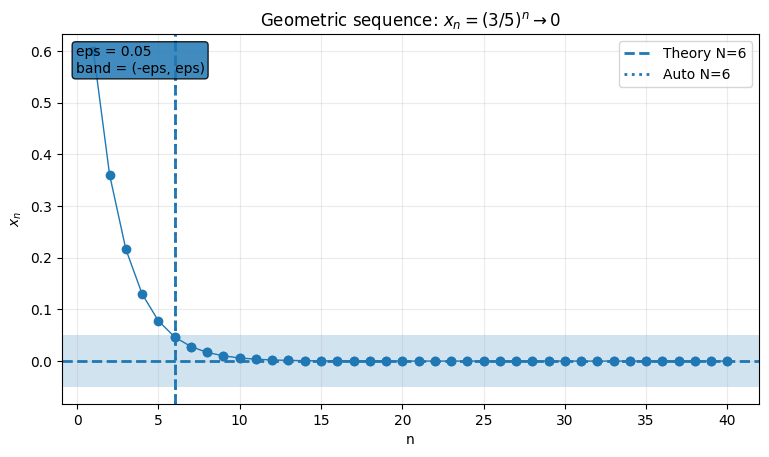

[Geometric] Theory N(eps) = 6
[Geometric] Auto   N(eps) = 6


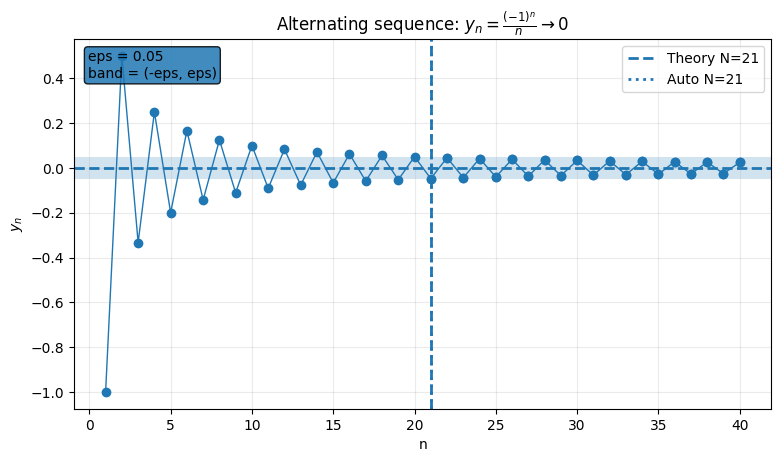

[Alternating] Theory N(eps) = 21
[Alternating] Auto   N(eps) = 21


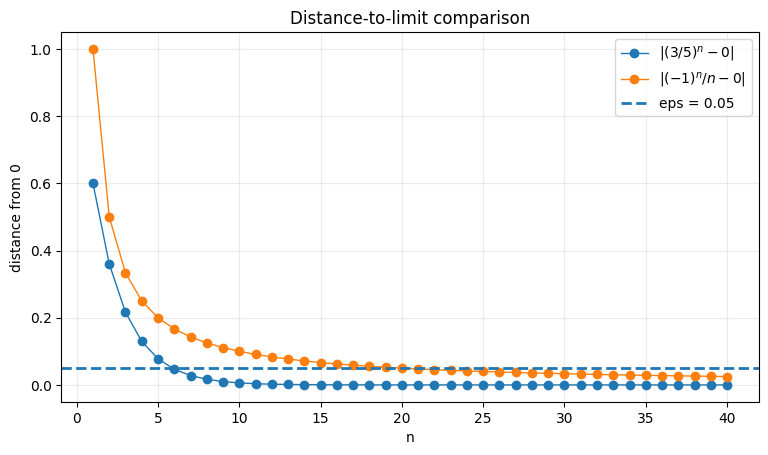

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, log

# ==========================================================
# Part A: x_n = (3/5)^n
# ==========================================================

def geometric_sequence(n):
    return (3/5) ** n

def N_geometric(eps):
    """
    Theoretical N(eps) for x_n = (3/5)^n -> 0
    """
    if eps >= 1:
        return 1
    return max(1, int(ceil(log(eps) / log(3/5))))

def first_stable_index_geometric(eps, n_max=200):
    """
    Smallest N in the plotted range such that for all n >= N,
    (3/5)^n < eps.
    """
    n = np.arange(1, n_max + 1)
    vals = geometric_sequence(n)
    inside = vals < eps

    suffix_all_inside = np.ones_like(inside, dtype=bool)
    suffix_all_inside[-1] = inside[-1]
    for k in range(len(inside) - 2, -1, -1):
        suffix_all_inside[k] = inside[k] and suffix_all_inside[k + 1]

    idx = np.where(suffix_all_inside)[0]
    if len(idx) == 0:
        return None
    return int(idx[0] + 1)  # 1-based

def plot_geometric(eps=0.05, n_max=40):
    n = np.arange(1, n_max + 1)
    vals = geometric_sequence(n)

    N_theory = N_geometric(eps)
    N_auto = first_stable_index_geometric(eps, n_max=n_max)

    plt.figure(figsize=(9, 4.8))

    # epsilon band around 0
    plt.axhspan(-eps, eps, alpha=0.20)
    plt.axhline(0, linestyle="--", linewidth=2)

    # sequence plot
    plt.plot(n, vals, marker="o", linewidth=1)

    # theory and auto vertical lines
    plt.axvline(N_theory, linestyle="--", linewidth=2, label=f"Theory N={N_theory}")
    if N_auto is not None:
        plt.axvline(N_auto, linestyle=":", linewidth=2, label=f"Auto N={N_auto}")

    # highlight tail
    plt.scatter(n[n >= N_theory], vals[n >= N_theory], s=35)

    plt.title(r"Geometric sequence: $x_n = (3/5)^n \to 0$")
    plt.xlabel("n")
    plt.ylabel(r"$x_n$")

    plt.text(
        0.02, 0.97,
        f"eps = {eps}\nband = (-eps, eps)",
        transform=plt.gca().transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.85)
    )

    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.25)
    plt.show()

    print(f"[Geometric] Theory N(eps) = {N_theory}")
    print(f"[Geometric] Auto   N(eps) = {N_auto}")


# ==========================================================
# Part B: y_n = (-1)^n / n
# ==========================================================

def alternating_sequence(n):
    return ((-1) ** n) / n

def alternating_distance(n):
    return np.abs(((-1) ** n) / n)

def N_alternating(eps):
    """
    Theoretical N(eps) for y_n = (-1)^n / n -> 0
    """
    return int(ceil(1/eps) + 1)

def first_stable_index_alternating(eps, n_max=200):
    """
    Smallest N in the plotted range such that for all n >= N,
    |(-1)^n / n| < eps.
    """
    n = np.arange(1, n_max + 1)
    vals = alternating_distance(n)
    inside = vals < eps

    suffix_all_inside = np.ones_like(inside, dtype=bool)
    suffix_all_inside[-1] = inside[-1]
    for k in range(len(inside) - 2, -1, -1):
        suffix_all_inside[k] = inside[k] and suffix_all_inside[k + 1]

    idx = np.where(suffix_all_inside)[0]
    if len(idx) == 0:
        return None
    return int(idx[0] + 1)

def plot_alternating(eps=0.05, n_max=40):
    n = np.arange(1, n_max + 1)
    vals = alternating_sequence(n)

    N_theory = N_alternating(eps)
    N_auto = first_stable_index_alternating(eps, n_max=n_max)

    plt.figure(figsize=(9, 4.8))

    # epsilon band around 0
    plt.axhspan(-eps, eps, alpha=0.20)
    plt.axhline(0, linestyle="--", linewidth=2)

    # sequence values
    plt.plot(n, vals, marker="o", linewidth=1)

    # theory and auto vertical lines
    plt.axvline(N_theory, linestyle="--", linewidth=2, label=f"Theory N={N_theory}")
    if N_auto is not None:
        plt.axvline(N_auto, linestyle=":", linewidth=2, label=f"Auto N={N_auto}")

    # highlight tail
    plt.scatter(n[n >= N_theory], vals[n >= N_theory], s=35)

    plt.title(r"Alternating sequence: $y_n = \frac{(-1)^n}{n} \to 0$")
    plt.xlabel("n")
    plt.ylabel(r"$y_n$")

    plt.text(
        0.02, 0.97,
        f"eps = {eps}\nband = (-eps, eps)",
        transform=plt.gca().transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.85)
    )

    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.25)
    plt.show()

    print(f"[Alternating] Theory N(eps) = {N_theory}")
    print(f"[Alternating] Auto   N(eps) = {N_auto}")


# ==========================================================
# Part C: Distance plots (optional but very informative)
# ==========================================================

def plot_distance_comparison(eps=0.05, n_max=40):
    n = np.arange(1, n_max + 1)

    geo_dist = geometric_sequence(n)          # since limit is 0
    alt_dist = alternating_distance(n)        # |(-1)^n/n|

    plt.figure(figsize=(9, 4.8))
    plt.plot(n, geo_dist, marker="o", linewidth=1, label=r"$|(3/5)^n-0|$")
    plt.plot(n, alt_dist, marker="o", linewidth=1, label=r"$|(-1)^n/n-0|$")
    plt.axhline(eps, linestyle="--", linewidth=2, label=f"eps = {eps}")

    plt.title("Distance-to-limit comparison")
    plt.xlabel("n")
    plt.ylabel("distance from 0")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()


# ==========================================================
# Run examples
# ==========================================================
plot_geometric(eps=0.05, n_max=40)
plot_alternating(eps=0.05, n_max=40)
plot_distance_comparison(eps=0.05, n_max=40)

## **(4) Conceptual Lesson**
These two examples illustrate two different mechanisms of convergence:

- Geometric shrinking, where the size decays multiplicatively;
- Oscillatory shrinking, where the sign changes but the absolute value tends to $0$.

The $\varepsilon$-$N$ definition is flexible enough to capture both phenomena with the same logical structure.

### **Pseudocode: ε–N Verification For the Two Example Sequences**

We now describe the computational logic used for the two sequences

$$
x_n=\left(\frac35\right)^n
\qquad\text{and}\qquad
y_n=\frac{(-1)^n}{n}.
$$

The goal is to verify numerically that, for a chosen tolerance \(\varepsilon>0\),

$$
n\ge N(\varepsilon)\quad\Longrightarrow\quad |x_n-0|<\varepsilon
$$

or

$$
n\ge N(\varepsilon)\quad\Longrightarrow\quad |y_n-0|<\varepsilon.
$$

#### **Algorithm A: Geometric Sequence $\left(\frac35\right)^n$**

```text
Input: tolerance ε > 0, plotting range n_max
Output: theoretical N(ε), automatic stable index N_auto

1. Define the sequence
       x_n = (3/5)^n

2. Compute the theoretical ε-index
       if ε ≥ 1:
            N = 1
       else:
            N = max(1, ceil( ln(ε) / ln(3/5) ))

3. Generate the values x_1, x_2, ..., x_{n_max}

4. Compute the first stable index N_auto:
       find the smallest N_auto such that
       for all n ≥ N_auto, x_n < ε

5. Plot:
       - the sequence x_n
       - the shaded ε-band (-ε, ε)
       - a vertical dashed line at N
       - a vertical dotted line at N_auto
       - highlight all terms with n ≥ N
```

#### **Algorithm B: Alternating Sequence $\frac{(-1)^n}{n}$**




```text
Input: tolerance ε > 0, plotting range n_max
Output: theoretical N(ε), automatic stable index N_auto

1. Define the sequence
       y_n = (-1)^n / n

2. Compute the theoretical ε-index
       N = ceil(1/ε) + 1

3. Generate the values y_1, y_2, ..., y_{n_max}

4. Compute the first stable index N_auto:
       find the smallest N_auto such that
       for all n ≥ N_auto, |y_n| < ε

5. Plot:
       - the sequence y_n
       - the shaded ε-band (-ε, ε)
       - a vertical dashed line at N
       - a vertical dotted line at N_auto
       - highlight all terms with n ≥ N

```



> In both algorithms, the shaded band represents the ball
>
> $$B(0,ε)=(−ε,ε).$$
>
> The dashed vertical line marks the proof-based index $N(ε)$, while the dotted vertical line marks the first automatically detected stable index. The computation therefore mirrors the mathematical definition:
>
>$$(∀ε>0)(∃N)(∀n≥N)∣x_n−0∣<ε.$$


